In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql import SparkSession
from pyspark.ml.feature import RobustScaler, VectorAssembler
from pyspark.ml.classification import LogisticRegression,RandomForestClassifier, GBTClassifier
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.sql.functions import col, when
import multiprocessing

In [3]:
df = pd.read_csv('data/diabetes_binary_health_indicators_BRFSS2015.csv')

In [4]:
df

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
253675,0.0,1.0,1.0,1.0,45.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,5.0,0.0,1.0,5.0,6.0,7.0
253676,1.0,1.0,1.0,1.0,18.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,4.0,0.0,0.0,1.0,0.0,11.0,2.0,4.0
253677,0.0,0.0,0.0,1.0,28.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,2.0,5.0,2.0
253678,0.0,1.0,0.0,1.0,23.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,7.0,5.0,1.0


Податочното множество е небалансирано така што имаме поголем процент на негативни примероци.

In [5]:
df.value_counts('Diabetes_binary', normalize=True) * 100


Diabetes_binary
0.0    86.066698
1.0    13.933302
Name: proportion, dtype: float64

### Поделба на податочното множество

In [6]:
online_df, offline_df = train_test_split(df, test_size=0.8, stratify=df['Diabetes_binary'])
online_df.to_csv('data/online.csv', index=False)
offline_df.to_csv('data/offline.csv', index=False)

### Offline фаза

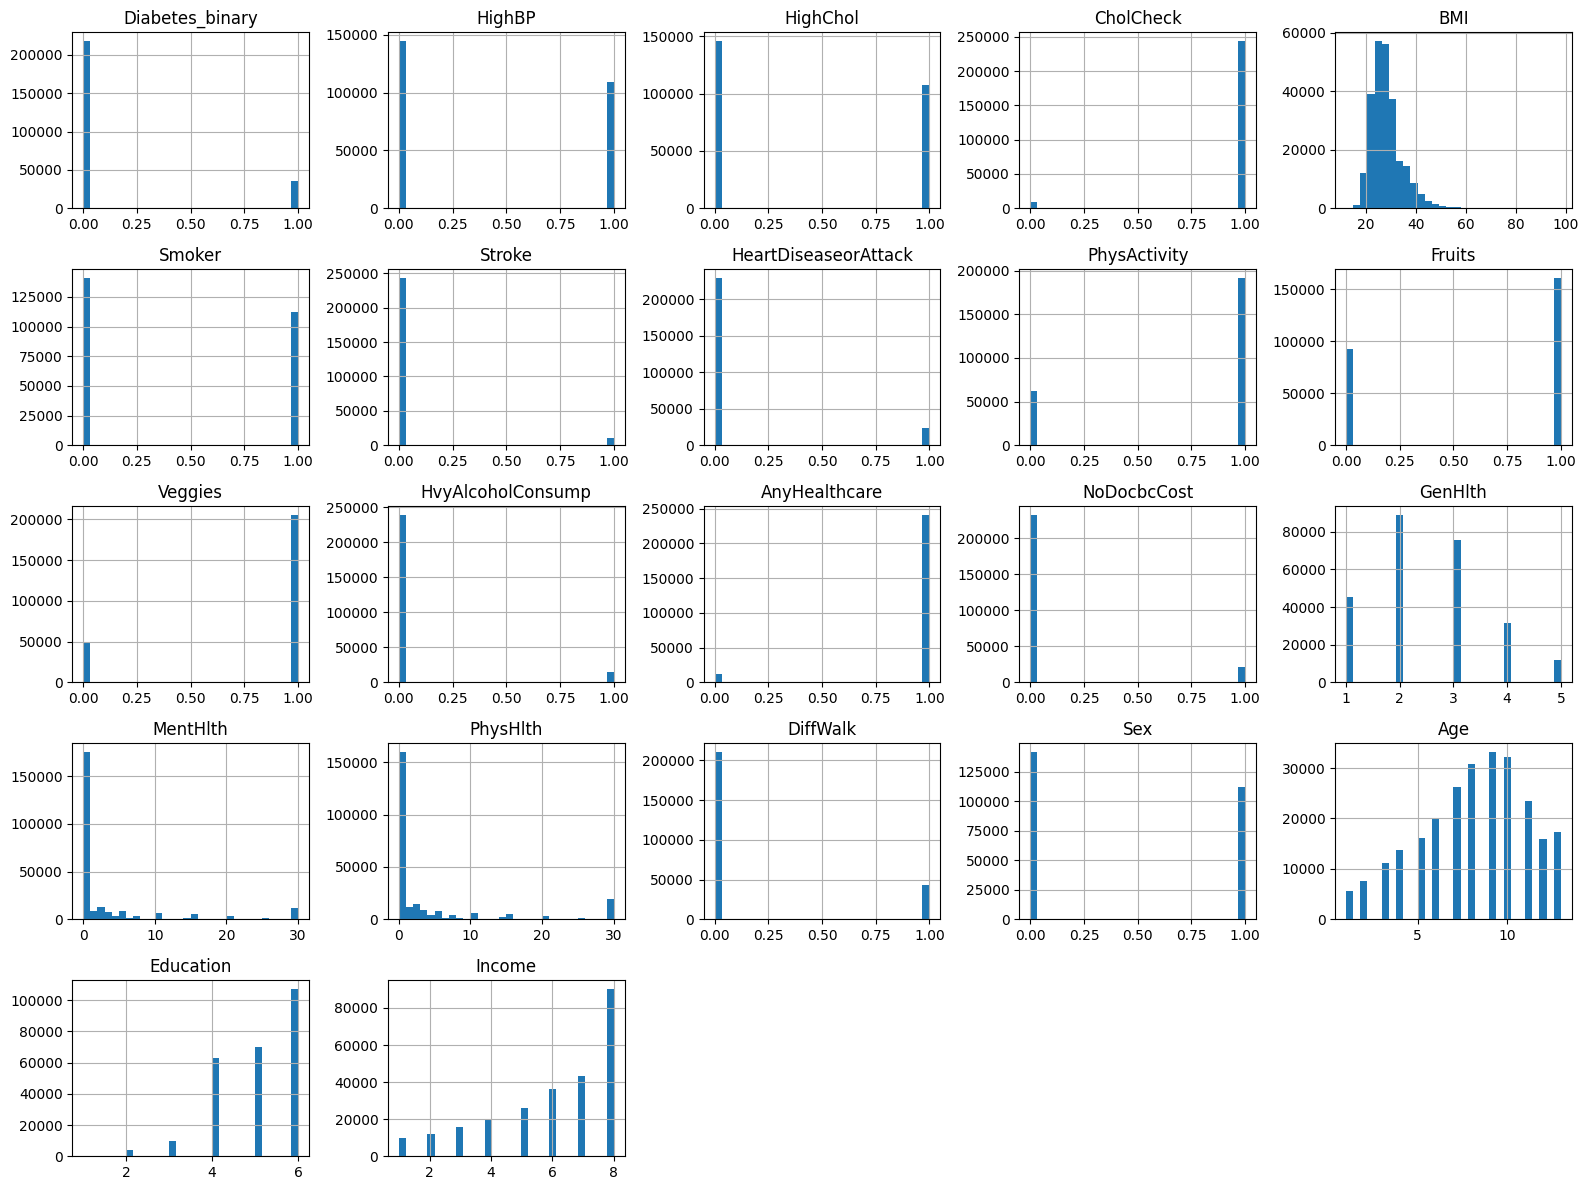

In [7]:
df.hist(
    figsize=(16, 12),
    bins=30
)
plt.tight_layout()
plt.show()

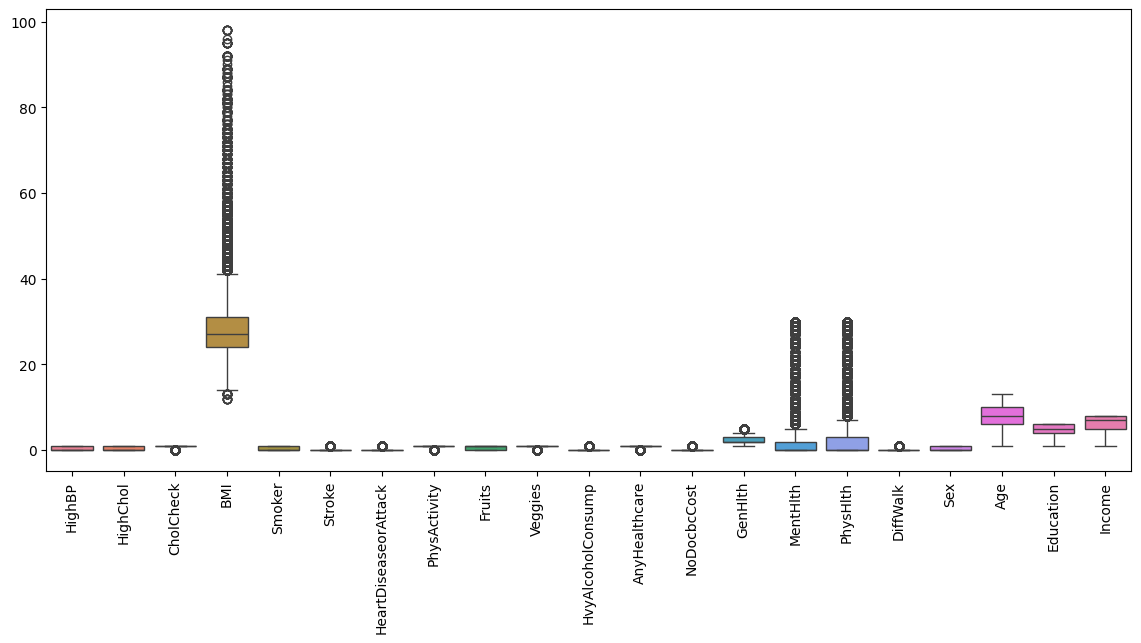

In [8]:
plt.figure(figsize=(14, 6))
sns.boxplot(data=df.drop(columns=['Diabetes_binary']))
plt.xticks(rotation=90)
plt.show()

In [9]:
spark = SparkSession.builder.appName("HW3-Diabetes-Health-Indicators-Dataset-Offline-Training").getOrCreate()

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/01/11 17:54:19 WARN Utils: Your hostname, Nikola, resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
26/01/11 17:54:19 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/01/11 17:54:20 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [10]:
df_offline = spark.read.csv(
    "data/offline.csv",
    header=True,
    inferSchema=True
)

По визуелизациите со histogram и boxplot се решив да ги скалирам колоните **BMI**, **MentHlth** и **PhysHlth** поради тоа што имаат аутлајери, а за скалирање ќе го искористам **RobustScaler** кој ја отстранува медијаната, ги скалира податоците според интеркварталното растојание односно помеѓу првиот и третиот квартал и е отпорен на аутлајери.

In [11]:
def fit_scaler(df, scale_cols):
    assembler = VectorAssembler(
        inputCols=scale_cols,
        outputCol="features_to_scale"
    )

    df_assembled = assembler.transform(df)

    scaler = RobustScaler(
        inputCol="features_to_scale",
        outputCol="scaled_features",
        withCentering=True,
        withScaling=True
    )

    scaler_model = scaler.fit(df_assembled)
    df_scaled = scaler_model.transform(df_assembled)

    return df_scaled, assembler, scaler_model

In [12]:
scale_cols = ["BMI", "MentHlth", "PhysHlth"]

df_offline_scaled, assembler, scaler_model = fit_scaler(
    df_offline,
    scale_cols
)

scaler_model.write().overwrite().save("models/robust_scaler")


По извршеното скалирање на непрекинатите карактеристики, скалираните и нескалираните карактеристики беа комбинирани во единствен features вектор со помош на VectorAssembler. Овој вектор се користи како влез за сите Spark ML класификациски модели.

In [13]:
unscaled_cols = [
    "HighBP", "HighChol", "CholCheck", "Smoker", "Stroke",
    "HeartDiseaseorAttack", "PhysActivity", "Fruits", "Veggies",
    "HvyAlcoholConsump", "AnyHealthcare", "NoDocbcCost",
    "GenHlth", "DiffWalk", "Sex", "Age", "Education", "Income"
]

final_assembler = VectorAssembler(
    inputCols=["scaled_features"] + unscaled_cols,
    outputCol="features"
)

df_offline_final = final_assembler.transform(df_offline_scaled)

Поради тоа што имаме небалансирано податочно множество каде што е поголем бројот на примероци од негативната класа, беше имплементирана стратегија за балансирање на класите со користење на `weightCol` параметар во Spark ML. Тежините на класите беа пресметани како инверзна фреквенција на појавување на секоја класа, со што грешките кај малцинската класа имаат поголемо влијание при обучувањето на моделите.

In [14]:
label_col = "Diabetes_binary"

class_counts = (
    df_offline_final
    .groupBy(label_col)
    .count()
    .collect()
)

counts = {row[label_col]: row["count"] for row in class_counts}
total = sum(counts.values())
num_classes = len(counts)

weights = {
    cls: total / (num_classes * cnt)
    for cls, cnt in counts.items()
}


df_offline_final = df_offline_final.withColumn(
    "weight",
    when(col(label_col) == 0, weights[0.0])
    .otherwise(weights[1.0])
)


При тренирање на моделите беше користен `CrossValidator`, при што моделите беа евалуирани преку пет различни поделби на податочното множество. За тестирање на различни комбинации на хиперпараметри беше искористен `ParamGridBuilder`.

In [15]:
models = [
    (
        "LogisticRegression",
        LogisticRegression(
            featuresCol="features",
            labelCol="Diabetes_binary",
            maxIter=50,
            weightCol="weight"
        ),
        ParamGridBuilder()
            .addGrid(LogisticRegression.regParam, [0.0, 0.01, 0.1])
            .addGrid(LogisticRegression.elasticNetParam, [0.0, 0.5])
            .build()
    ),
    (
        "RandomForest",
        RandomForestClassifier(
            featuresCol="features",
            labelCol="Diabetes_binary",
            seed=42,
            weightCol="weight"
        ),
        ParamGridBuilder()
            .addGrid(RandomForestClassifier.numTrees, [50, 100])
            .addGrid(RandomForestClassifier.maxDepth, [10, 20])
            .addGrid(RandomForestClassifier.minInstancesPerNode, [1,5])
            .build()
    ),
    (
        "GBT",
        GBTClassifier(
            featuresCol="features",
            labelCol="Diabetes_binary",
            seed=42,
            weightCol="weight",

        ),
        ParamGridBuilder()
            .addGrid(GBTClassifier.maxDepth, [3, 5])
            .addGrid(GBTClassifier.stepSize, [0.05, 0.1])
            .build()
    )
]


In [16]:
train_df, test_df = df_offline_final.randomSplit([0.8, 0.2], seed=42)

In [17]:
evaluator = MulticlassClassificationEvaluator(
    labelCol="Diabetes_binary",
    predictionCol="prediction",
    metricName="f1"
)

best_models = {}

for name, estimator, param_grid in models:
    cv = CrossValidator(
        estimator=estimator,
        estimatorParamMaps=param_grid,
        evaluator=evaluator,
        numFolds=5,
        parallelism=multiprocessing.cpu_count() # use all available CPU cores or set to desired number
    )

    cv_model = cv.fit(train_df)

    best_models[name] = cv_model.bestModel
    print(f'{name} F1 = {cv_model.avgMetrics[0]:.4f}')

26/01/11 17:54:36 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
26/01/11 17:54:41 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
26/01/11 17:54:44 WARN BlockManager: Block rdd_600_4 already exists on this machine; not re-adding it
26/01/11 17:54:45 WARN BlockManager: Block rdd_600_2 already exists on this machine; not re-adding it
26/01/11 17:54:45 WARN BlockManager: Block rdd_600_3 already exists on this machine; not re-adding it
26/01/11 17:54:45 WARN BlockManager: Block rdd_600_0 already exists on this machine; not re-adding it


LogisticRegression F1 = 0.7710


26/01/11 17:55:04 WARN BlockManager: Block rdd_3268_1 already exists on this machine; not re-adding it
26/01/11 17:55:04 WARN BlockManager: Block rdd_3268_0 already exists on this machine; not re-adding it


RandomForest F1 = 0.7633
GBT F1 = 0.7597


In [18]:
best_model= None
best_name = None
best_f1 = -1

for name, model in best_models.items():
    predictions = model.transform(test_df)
    test_f1 = evaluator.evaluate(predictions)
    print(f'{name} Test F1 = {test_f1:.4f}')
    if test_f1 > best_f1:
        best_f1 = test_f1
        best_model = model
        best_name = name

LogisticRegression Test F1 = 0.7660
RandomForest Test F1 = 0.7596
GBT Test F1 = 0.7550


In [19]:
print(f'Best model: {best_name} with F1 = {best_f1:.4f}')

Best model: LogisticRegression with F1 = 0.7660


In [20]:
best_model.write().overwrite().save(f"models/best_model")


In [21]:
spark.stop()